<a href="https://colab.research.google.com/github/rafaelescoriza/PUC_CienciaDadosML/blob/main/v05_MVP_RafaelEscoriza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MVP de Machine Learning e Analytics

**Nome:** Rafael de Miras Escoriza

**Matrícula:** 4052026000297

**Data:** 05/07/2026

**Dataset:** Athlete Training Performance and Fatigue Dataset
(https://www.kaggle.com/datasets/jashanpreetsingh645/athlete-training-performance-and-fatigue-dataset/data)

**Tipo de problema:** Classificação

---



# [1] Definição do problema



## 1.1 Descrição do problema

O problema está relacionado à prevenção de lesões em atletas não profissionais. A partir da análise de parâmetros coletados ao longo de um período de treinamento, busca-se identificar fatores que possam indicar maior propensão a contusões.

O modelo tem como objetivo classificar se um indivíduo apresenta tendência a desenvolver lesões, considerando variáveis como carga de treino, intensidade das atividades, atributos físicos e frequência dos treinamentos. Dessa forma, o sistema apoia a tomada de decisão na elaboração e no ajuste de programas de treinamento.

Os principais usuários dessa solução seriam profissionais da área de Educação Física, treinadores e praticantes de esportes amadores que desejam monitorar riscos e otimizar seu desempenho de forma segura.

Esse problema é relevante porque lesões podem comprometer a saúde, a continuidade da prática esportiva e a qualidade de vida dos atletas. A identificação precoce de fatores de risco permite a adoção de medidas preventivas, contribuindo para treinos mais seguros e eficientes.

## 1.2 Objetivo do problema

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever contusões a partir de atributos físicos e intensidade de treinos, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.

**Objetivo deste trabalho:**  
> Previsão de contusões

## 1.3 Classificação do problema

**Tipo escolhido**: Classificação

**Justificativa**: Foi definido a classificação para trazer uma resposta direta, sim ou não, se uma pessoa tem risco de contusão devido a seus atributos físicos e intensidade de treino

## 1.4 Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |


## 1.5 Critérios e Hipoteses

# [2] Ambientes

## 2.1 Bibliotecas

In [72]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split # para particionar em bases de treino e teste (holdout)
from sklearn.model_selection import KFold # para preparar os folds da validação cruzada
from sklearn.model_selection import cross_val_score # para executar a validação cruzada
from sklearn.metrics import accuracy_score # para a exibição da acurácia do modelo
from sklearn.neighbors import KNeighborsClassifier # algoritmo KNN
from sklearn.tree import DecisionTreeClassifier # algoritmo Árvore de Classificação
from sklearn.naive_bayes import GaussianNB # algoritmo Naive Bayes
from sklearn.svm import SVC # algoritmo SVM

from sklearn.ensemble import ExtraTreesClassifier # ExtraTrees, para a Importância de Atributos
from sklearn.feature_selection import SelectKBest # para a Seleção Univariada
from sklearn.feature_selection import f_classif # para o teste ANOVA da Seleção Univariada
from sklearn.feature_selection import RFE # para a Eliminação Recursiva de Atributos
from sklearn.linear_model import LogisticRegression # Regressão Logística, para a Eliminação Recursiva de Atributos


import os, random, time, sys, math
import time
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score)

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform


## 2.2 Funções

In [73]:
def evaluate_classification(y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    auc = roc_auc_score(y_true, proba[:,1]) if (proba is not None and proba.shape[1]==2) else np.nan
    return {"accuracy": acc, "f1_weighted": f1w, "roc_auc": auc}

# [3] Carga de dados

## 3.1 Fonte de dados

**Nome dataset**: Athlete Training Performance and Fatigue Dataset

**Link da fonte**: https://www.kaggle.com/datasets/jashanpreetsingh645/athlete-training-performance-and-fatigue-dataset/data

**Escolha**: Entender quais parametros são importantes para uma futura contusão em atletas

**Restrições e condições**: RESPONDER

**Ética, privacidade, confidencialidade ou licença**: RESPONDER

## 3.2 Carga de dados

In [131]:
dataset_atletas = pd.read_csv("https://raw.githubusercontent.com/rafaelescoriza/PUC_CienciaDadosML/refs/heads/main/athlete_data.csv")

## 3.3 Visão geral do dataset

### 3.3.1 Tabela

In [132]:
dataset_atletas['training_num'] = dataset_atletas['Training_Intensity'].map({
    'Low': 1,
    'Medium': 2,
    'High': 3
})

## Hot-one enconding sera aprendido em outro modulo, porem tive que utlizar a tecnica para descrever "Male = 1 / Female = 0 // Yes = 1 / No = 0"
## Não houve exclusão de segurança, pois não havia dados sensíveis. Exclusão apenas das colunas descritivas para execução das ferramentas de análise

dataset_atletas = pd.get_dummies(
    dataset_atletas,
    columns=['Gender', 'Injury_Indicator'],
    drop_first=True,
    dtype=int
)


dataset_atletas = dataset_atletas.drop(
    ['Athlete_ID', 'Training_Intensity'],
    axis=1
)


dataset_atletas.head()

,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,heartbeat,training_num,Gender_Male,Injury_Indicator_Yes
0,24,188,50,12,2,1,3,7,3,5,5,4,83,1,1,1
1,37,166,85,2,2,2,2,9,5,9,5,7,73,2,0,1
2,32,188,75,12,2,3,2,9,9,4,8,8,64,3,0,0
3,28,171,78,5,2,3,1,5,8,1,9,3,77,2,0,1
4,25,175,70,12,1,0,6,1,2,4,9,9,78,2,1,0


### 3.3.2 Formato do dataset e tipos de dados

In [133]:
print("Formato do dataset:", dataset_atletas.shape)
print("\nTipos de dados:")
display(dataset_atletas.dtypes.to_frame("tipo"))

Formato do dataset: (500, 16)

Tipos de dados:


,tipo
Age,int64
Height_cm,int64
Weight_kg,int64
Training_Hours_Per_Week,int64
Recovery_Days_Per_Week,int64
Match_Count_Per_Week,int64
Rest_Between_Events_Days,int64
Fatigue_Score,int64
Performance_Score,int64
Team_Contribution_Score,int64


### 3.3.3 Valores ausentes

In [77]:
print("\nValores ausentes por coluna:")
display(dataset_atletas.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Age,0
Height_cm,0
Weight_kg,0
Training_Hours_Per_Week,0
Recovery_Days_Per_Week,0
Match_Count_Per_Week,0
Rest_Between_Events_Days,0
Fatigue_Score,0
Performance_Score,0
Team_Contribution_Score,0


### 3.3.4 Duplicatas

In [78]:
print("\nDuplicatas:", dataset_atletas.duplicated().sum())


Duplicatas: 0


### 3.3.5 Dicionario de dados (PREENCHER)

# [4] Análise exploratoria dos dados

## 4.1 Distribuição do target;

*   distribuição do target;
*   distribuição de variáveis importantes;
*   relação entre variáveis e target;
*   identificação de desbalanceamento, outliers ou padrões relevantes;
*   hipóteses que surgem a partir dos dados.   

Comentário: siga a lógica do MVP de pré-processamento: não basta mostrar
gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.






In [120]:
# TARGET é o meu indicador de contusão

TARGET = "Injury_Indicator_Yes"
PROBLEM_TYPE = "classificacao"
SEED = 42

if TARGET is not None and TARGET in dataset_atletas.columns:
    print("Distribuição do target:")
    display(dataset_atletas[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((dataset_atletas[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

Distribuição do target:


,contagem
Injury_Indicator_Yes,
1,256
0,244


,percentual
Injury_Indicator_Yes,
1,51.2
0,48.8


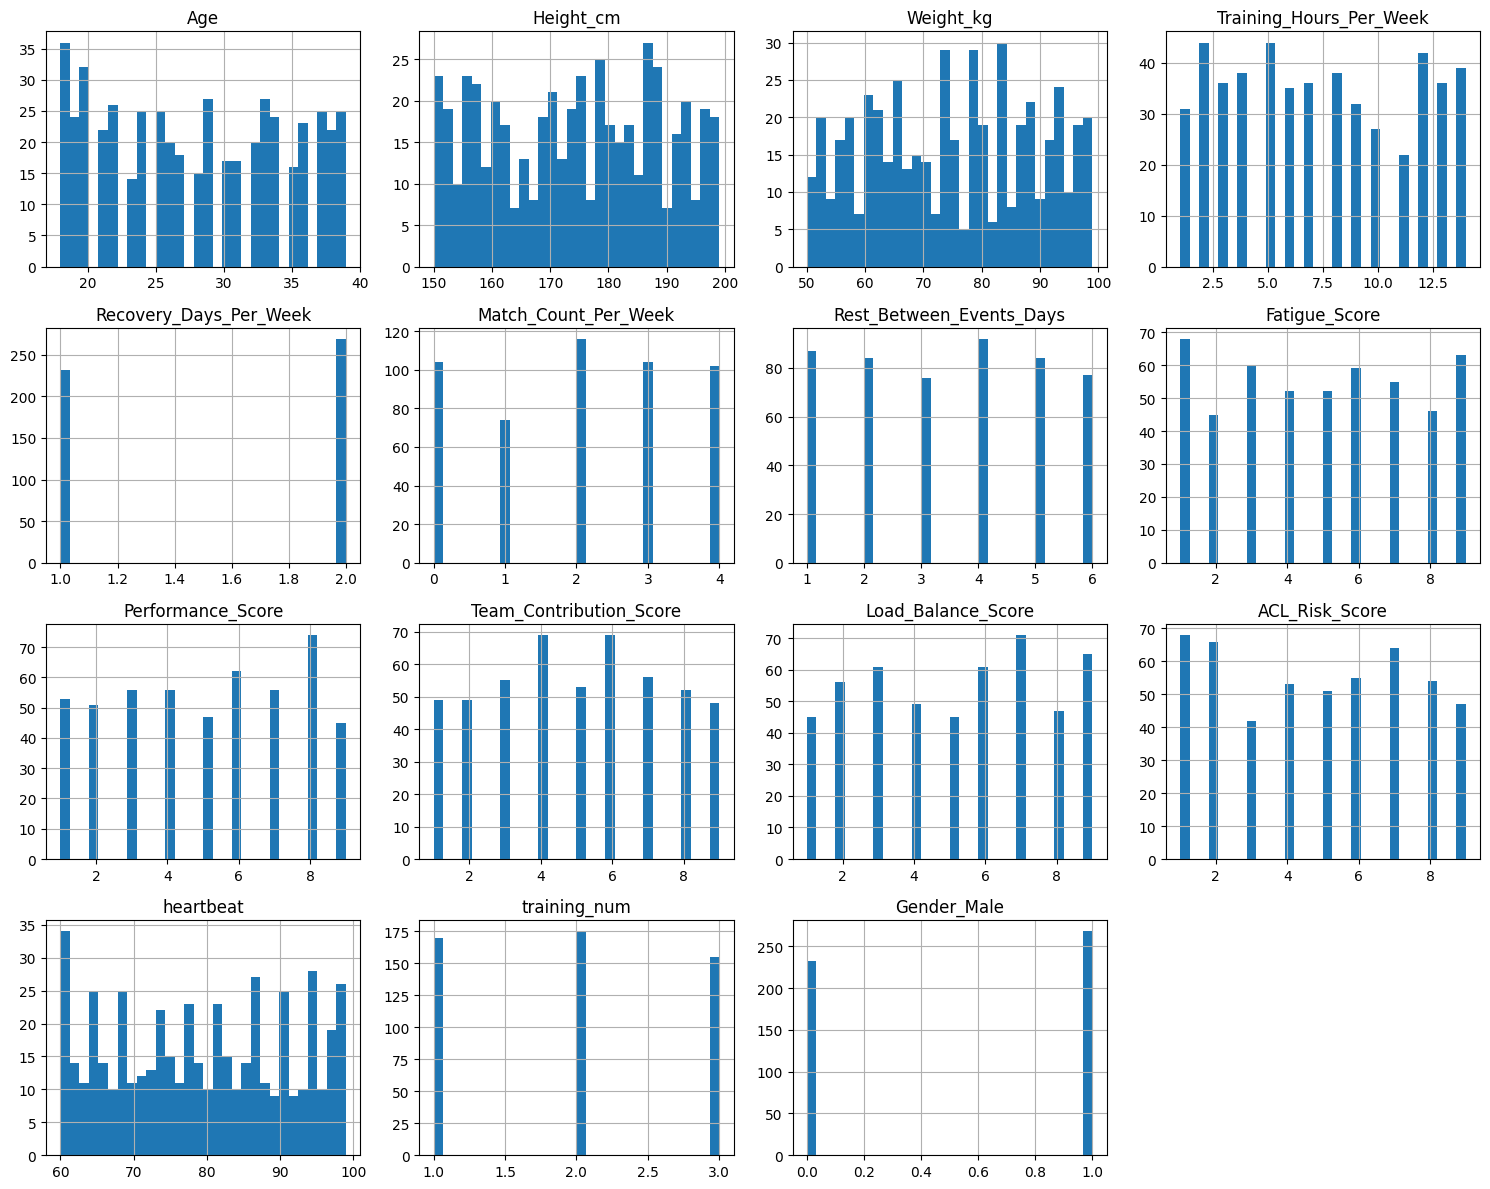

In [80]:
# Visualização da distribuição dos parametros

numeric_cols = dataset_atletas.select_dtypes(include=np.number).columns.tolist()
categorical_cols = dataset_atletas.select_dtypes(exclude=np.number).columns.tolist()

if TARGET in numeric_cols:
    numeric_cols_without_target = [c for c in numeric_cols if c != TARGET]
else:
    numeric_cols_without_target = numeric_cols

dataset_atletas[numeric_cols_without_target].hist(
    bins=30,
    figsize=(15, 12)
)
plt.tight_layout()
plt.show()




Escreva aqui os principais achados da EDA.

**Exemplo de perguntas para responder:**
- O target está balanceado?
- Existem valores ausentes relevantes?
- Há variáveis com escala muito diferente?
- Há categorias raras?
- Existem padrões que sugerem quais modelos podem funcionar melhor?
- Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?

**Síntese:**  
> **O Target possuí uma distribuição quase 50/50 de casos de contusão ou não dos atletas, e uma boa variabilidade de dados, sem apresentar dados ausentes. Por isso, a quantidade de dados é de boa qualidade, porém não há indicios de quais serão melhores utilizados.**

## 4.1 Comparação dos modelos com todos atributos

In [81]:
array = dataset_atletas.values
X = array[:,0:15] # atributos
y = array[:,15] # classe (target)

## Usaremos a divisão 70% treino / 30% Teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=8) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=8) # faz o particionamento em 10 folds

KNN: 0.402857 (0.069341)
CART: 0.457143 (0.061279)
NB: 0.485714 (0.052683)
SVM: 0.537143 (0.082610)


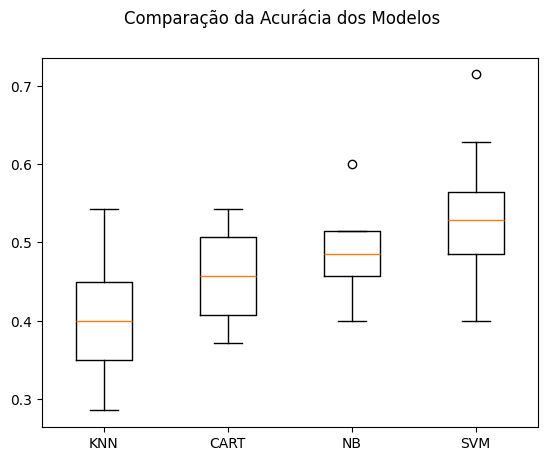

In [104]:
# Definindo uma seed global para esta célula de código
np.random.seed(SEED)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))



# Avaliando um modelo por vez
for name, model in models:
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()) # média e desvio padrão dos 10 resultados da validação cruzada
  print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação da Acurácia dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

### 4.1.1. Acurácia

In [105]:
# Criando um modelo com todo o conjunto de treino
model = SVC()
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)

# Estimando a acurácia no conjunto de teste
print(accuracy_score(y_test, predictions))

0.5333333333333333


## 4.2 Separando variavéis (Feature Selection)

### 4.2.1 SelectKbest

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.

In [106]:
## Já definida separação 70/30

array = dataset_atletas.values
X = array[:,0:15] # atributos
y = array[:,15] # classe (target)

# Seleção de atributos com SelectKBest
best_var = SelectKBest(score_func=f_classif, k=10)


# Executa a função de pontuação em (X, y) e obtém os atributos selecionados
fit = best_var.fit(X, y)

# Reduz X para os atributos selecionados
features = fit.transform(X)

# Resultados
print('\nNúmero original de atributos:', X.shape[1])
print('\nNúmero reduzido de atributos:', features.shape[1])


# Exibe os atributos orginais
print("\nAtributos Originais:", dataset_atletas.columns[0:15])

# Exibe as pontuações de cada atributos e os 4 escolhidas (com as pontuações mais altas)
np.set_printoptions(precision=3) # 3 casas decimais
print("\nScores dos Atributos Originais:", fit.scores_)

print("\nAtributos Selecionados:", best_var.get_feature_names_out(input_features=dataset_atletas.columns[0:15]))


Número original de atributos: 15

Número reduzido de atributos: 10

Atributos Originais: Index(['Age', 'Height_cm', 'Weight_kg', 'Training_Hours_Per_Week',
       'Recovery_Days_Per_Week', 'Match_Count_Per_Week',
       'Rest_Between_Events_Days', 'Fatigue_Score', 'Performance_Score',
       'Team_Contribution_Score', 'Load_Balance_Score', 'ACL_Risk_Score',
       'heartbeat', 'training_num', 'Gender_Male'],
      dtype='object')

Scores dos Atributos Originais: [0.387 0.854 0.093 2.595 0.718 0.021 0.26  0.132 0.705 0.075 1.199 0.414
 1.075 0.135 1.675]

Atributos Selecionados: ['Age' 'Height_cm' 'Training_Hours_Per_Week' 'Recovery_Days_Per_Week'
 'Rest_Between_Events_Days' 'Performance_Score' 'Load_Balance_Score'
 'ACL_Risk_Score' 'heartbeat' 'Gender_Male']


KNN: 0.474286 (0.087785)
CART: 0.500000 (0.092361)
NB: 0.511429 (0.053376)
SVM: 0.528571 (0.070276)


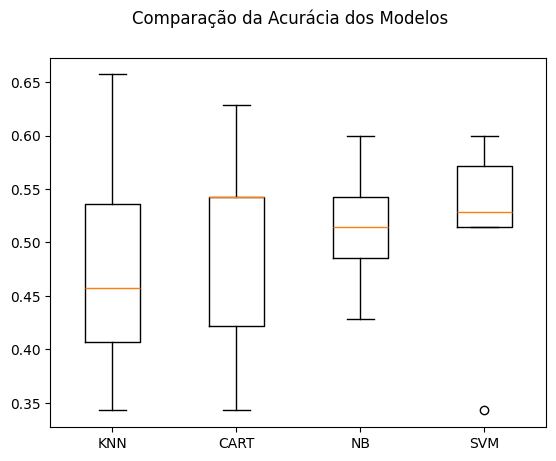

In [108]:
dataset_reduzido = dataset_atletas[
    ['Age', 'Height_cm', 'Training_Hours_Per_Week', 'Recovery_Days_Per_Week',
 'Rest_Between_Events_Days', 'Performance_Score', 'Load_Balance_Score',
 'ACL_Risk_Score', 'heartbeat', 'Gender_Male']
]

array = dataset_reduzido.values
X = array[:,0:9] # atributos
y = array[:,9] # classe (target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=8) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=8) # faz o particionamento em 10 folds



# Definindo uma seed global para esta célula de código
np.random.seed(SEED)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))




# Avaliando um modelo por vez
for name, model in models:
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()) # média e desvio padrão dos 10 resultados da validação cruzada
  print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação da Acurácia dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()





Selecionado 10 atributos por teste manual

#### 4.2.1.1 Acurácia



In [109]:
# Criando um modelo com todo o conjunto de treino
model = SVC()
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)

# Estimando a acurácia no conjunto de teste
print(accuracy_score(y_test, predictions))


0.5533333333333333


### 4.2.2 Recursiva

In [110]:
# Eliminação Recursiva de Atributos
array = dataset_atletas.values
X = array[:,0:15] # atributos
y = array[:,15] # classe (target)


# Criação do modelo
modelo = LogisticRegression(max_iter=200)

# Eliminação Recursiva de Atributos
rfe = RFE(modelo, n_features_to_select=6)
fit = rfe.fit(X, y)


# Print dos resultados
print("Atributos Originais:", dataset_atletas.columns[0:15])

# Exibe os atributos selecionados (marcados como True em "Atributos Selecionados"
# e com valor 1 em "Ranking dos Atributos")
print("\nAtributos Selecionados: %s" % fit.support_)
print("\nRanking de atributos: %s" % fit.ranking_)
print("\nQtd de melhores Atributos: %d" % fit.n_features_)
print("\nNomes dos Atributos Selecionados: %s" % fit.get_feature_names_out(input_features=dataset_atletas.columns[0:15]))



Atributos Originais: Index(['Age', 'Height_cm', 'Weight_kg', 'Training_Hours_Per_Week',
       'Recovery_Days_Per_Week', 'Match_Count_Per_Week',
       'Rest_Between_Events_Days', 'Fatigue_Score', 'Performance_Score',
       'Team_Contribution_Score', 'Load_Balance_Score', 'ACL_Risk_Score',
       'heartbeat', 'training_num', 'Gender_Male'],
      dtype='object')

Atributos Selecionados: [False False False  True  True False False False  True False  True False
 False  True  True]

Ranking de atributos: [ 6 10  9  1  1  8  3  5  1  4  1  2  7  1  1]

Qtd de melhores Atributos: 6

Nomes dos Atributos Selecionados: ['Training_Hours_Per_Week' 'Recovery_Days_Per_Week' 'Performance_Score'
 'Load_Balance_Score' 'training_num' 'Gender_Male']


KNN: 0.480000 (0.103648)
CART: 0.517143 (0.100975)
NB: 0.448571 (0.087645)
SVM: 0.500000 (0.083054)


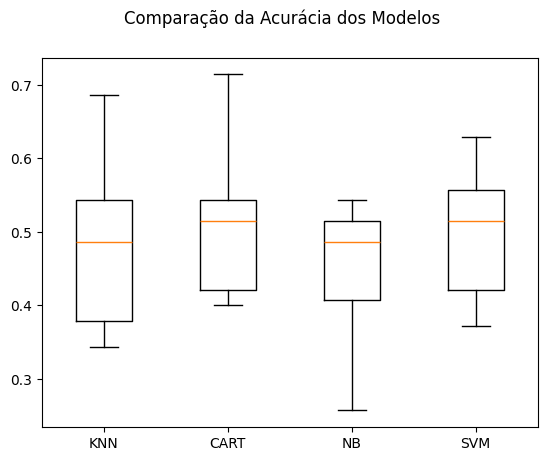

In [88]:
dataset_reduzido = dataset_atletas[
    ['Training_Hours_Per_Week', 'Recovery_Days_Per_Week', 'Performance_Score',
 'Load_Balance_Score', 'training_num', 'Gender_Male']
]

array = dataset_reduzido.values
X = array[:,0:5] # atributos
y = array[:,5] # classe (target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=8) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=8) # faz o particionamento em 10 folds

# Definindo uma seed global para esta célula de código
np.random.seed(SEED)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))


# Avaliando um modelo por vez
for name, model in models:
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()) # média e desvio padrão dos 10 resultados da validação cruzada
  print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação da Acurácia dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

#### Acuracia

In [111]:
# Criando um modelo com todo o conjunto de treino
model =  DecisionTreeClassifier()
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)

# Estimando a acurácia no conjunto de teste
print(accuracy_score(y_test, predictions))

0.52


### 4.2.2 Ensembles

KNN: 0.468571 (0.066639)
CART: 0.514286 (0.075593)
NB: 0.434286 (0.045714)
SVM: 0.537143 (0.066148)
Bagging: 0.465714 (0.055769)
RF: 0.462857 (0.075377)
ET: 0.497143 (0.083005)
Ada: 0.482857 (0.054884)
GB: 0.540000 (0.060542)
Voting: 0.497143 (0.073623)


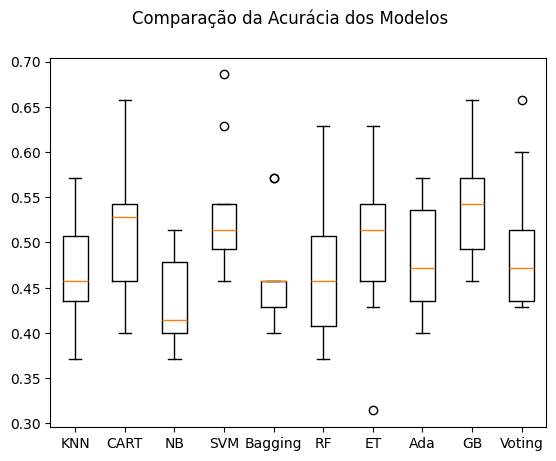

In [112]:
array = dataset_atletas.values
X = array[:,0:15] # atributos
y = array[:,15] # classe (target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=8) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=8) # faz o particionamento em 10 folds

# Definindo uma seed global para esta célula de código
np.random.seed(SEED)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Definindo os parâmetros do classificador base para o BaggingClassifier
base = DecisionTreeClassifier()
num_trees = 100
max_features = 3

# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Criando os ensembles e adicionando-os na lista de modelos
models.append(('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees)))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(bases)))

# Avaliando um modelo por vez
for name, model in models:
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()) # média e desvio padrão dos 10 resultados da validação cruzada
  print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação da Acurácia dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()



##### 4.2.2.1.1 Acuracia

In [113]:
# Criando um modelo com todo o conjunto de treino
model = GradientBoostingClassifier(n_estimators=num_trees)
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)

# Estimando a acurácia no conjunto de teste
print(accuracy_score(y_test, predictions))

0.52


### 4.2.3 Extra Tree

In [114]:
# Importância de Atributos com ExtraTrees
array = dataset_atletas.values
X = array[:,0:15] # atributos
y = array[:,15] # classe (target)

# Criação do modelo para seleção de atributos
modelo = ExtraTreesClassifier(n_estimators=100)
modelo.fit(X,y)

print(X.shape)

# Exibe os atributos orginais
print("\nAtributos Originais:", dataset_atletas.columns[0:15])

# Exibe a pontuação de importância para cada atributo (quanto maior a pontuação, mais importante é o atributo).
print(modelo.feature_importances_)

(500, 15)

Atributos Originais: Index(['Age', 'Height_cm', 'Weight_kg', 'Training_Hours_Per_Week',
       'Recovery_Days_Per_Week', 'Match_Count_Per_Week',
       'Rest_Between_Events_Days', 'Fatigue_Score', 'Performance_Score',
       'Team_Contribution_Score', 'Load_Balance_Score', 'ACL_Risk_Score',
       'heartbeat', 'training_num', 'Gender_Male'],
      dtype='object')
[0.074 0.074 0.076 0.082 0.037 0.065 0.071 0.071 0.068 0.072 0.075 0.074
 0.075 0.057 0.03 ]


KNN: 0.308571 (0.037904)
CART: 0.300000 (0.048234)
NB: 0.391429 (0.072337)
SVM: 0.391429 (0.070044)
Bagging: 0.311429 (0.081266)
RF: 0.308571 (0.061012)
ET: 0.302857 (0.042762)
Ada: 0.345714 (0.064460)
GB: 0.322857 (0.057214)
Voting: 0.388571 (0.061545)


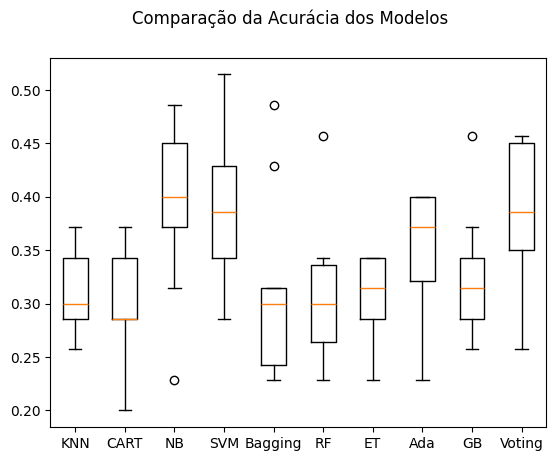

In [93]:
dataset_reduzido = dataset_atletas[
    ['Age', 'Weight_kg','Training_Hours_Per_Week',
 'training_num']
]

array = dataset_reduzido.values
X = array[:,0:3] # atributos
y = array[:,3] # classe (target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=8) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=8) # faz o particionamento em 10 folds

# Definindo uma seed global para esta célula de código
np.random.seed(SEED)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Definindo os parâmetros do classificador base para o BaggingClassifier
base = DecisionTreeClassifier()
num_trees = 100
max_features = 3

# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Criando os ensembles e adicionando-os na lista de modelos
models.append(('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees)))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(bases)))



# Avaliando um modelo por vez
for name, model in models:
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()) # média e desvio padrão dos 10 resultados da validação cruzada
  print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação da Acurácia dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()




#### 4.2.3.1 Acurácia

In [115]:
# Criando um modelo com todo o conjunto de treino
model = SVC()
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)

# Estimando a acurácia no conjunto de teste
print(accuracy_score(y_test, predictions))

0.4533333333333333


## 4.3 Normalização e padronização

KNN-orig: 0.469 (0.067)
CART-orig: 0.514 (0.076)
NB-orig: 0.434 (0.046)
SVM-orig: 0.537 (0.066)
Bag-orig: 0.466 (0.056)
RF-orig: 0.463 (0.075)
ET-orig: 0.497 (0.083)
Ada-orig: 0.483 (0.055)
GB-orig: 0.540 (0.061)
Vot-orig: 0.497 (0.074)
KNN-padr: 0.520 (0.076)
CART-padr: 0.514 (0.081)
NB-padr: 0.434 (0.046)
SVM-padr: 0.491 (0.054)
Bag-padr: 0.503 (0.051)
RF-padr: 0.454 (0.050)
ET-padr: 0.466 (0.066)
Ada-padr: 0.483 (0.055)
GB-padr: 0.529 (0.059)
Vot-padr: 0.469 (0.029)
KNN-norm: 0.549 (0.049)
CART-norm: 0.500 (0.073)
NB-norm: 0.434 (0.046)
SVM-norm: 0.531 (0.068)
Bag-norm: 0.514 (0.082)
RF-norm: 0.509 (0.054)
ET-norm: 0.494 (0.071)
Ada-norm: 0.483 (0.055)
GB-norm: 0.531 (0.057)
Vot-norm: 0.494 (0.061)


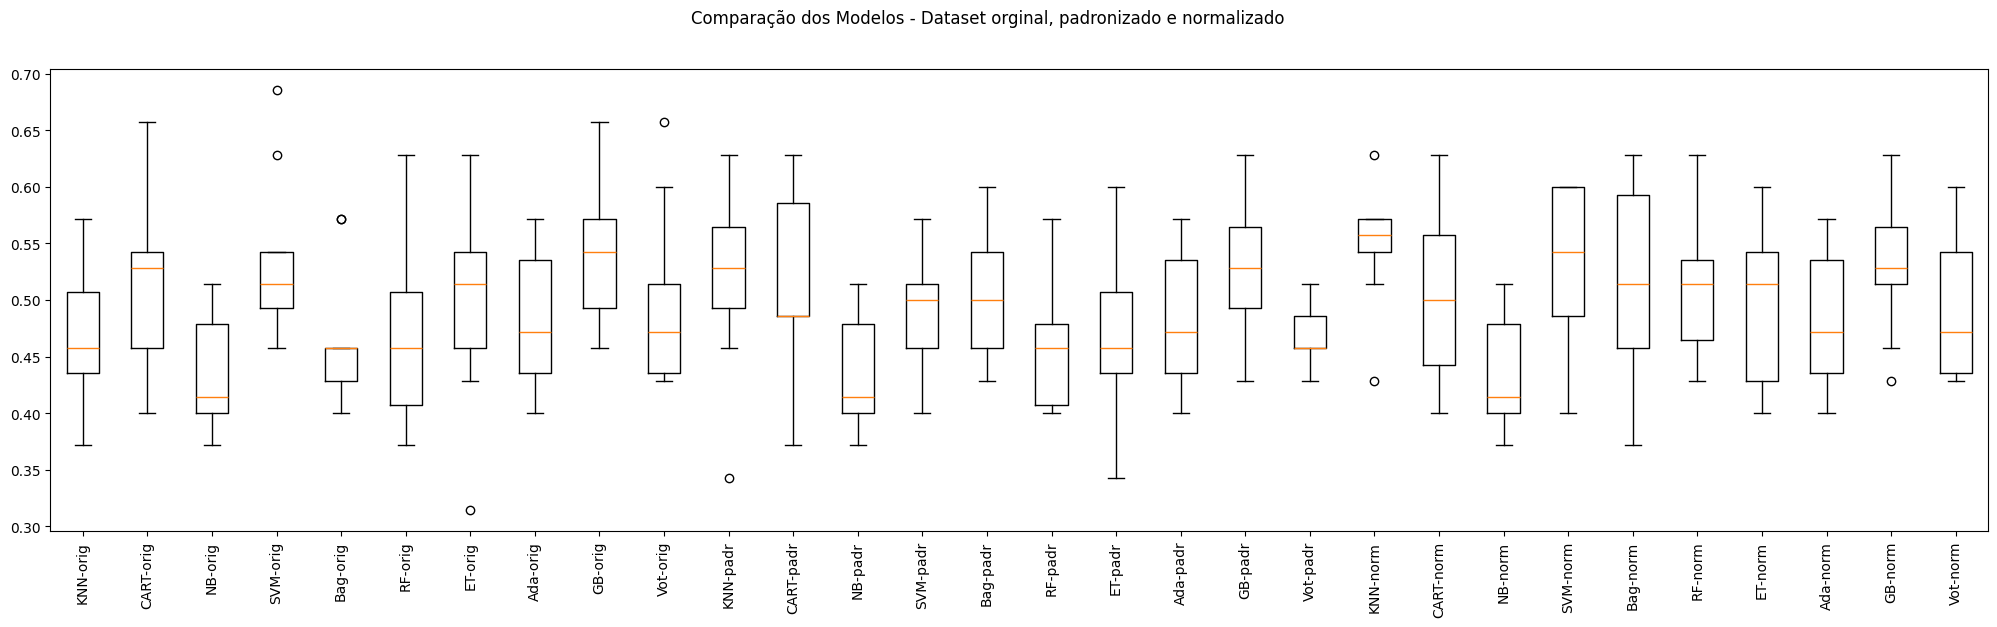

Sem tratamento de missings: knn-orig - Melhor: 0.511429 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 21}
Sem tratamento de missings: knn-padr - Melhor: 0.562857 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 17}
Sem tratamento de missings: knn-norm - Melhor: 0.568571 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 9}


LogisticRegression(max_iter=200)

In [116]:
array = dataset_atletas.values
X = array[:,0:15] # atributos
y = array[:,15] # classe (target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=8) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=8) # faz o particionamento em 10 folds

# Definindo uma seed global para esta célula de código
np.random.seed(SEED)

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

models = []
results = []
names = []

# Montando os models

knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())
bagging = ('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees))
random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
voting = ('Voting', VotingClassifier(bases))


# Dataset original
models.append(('KNN-orig', Pipeline([knn])))
models.append(('CART-orig', Pipeline([cart])))
models.append(('NB-orig', Pipeline([naive_bayes])))
models.append(('SVM-orig', Pipeline([svm])))
models.append(('Bag-orig', Pipeline([bagging])))
models.append(('RF-orig', Pipeline([random_forest])))
models.append(('ET-orig', Pipeline([extra_trees])))
models.append(('Ada-orig', Pipeline([adaboost])))
models.append(('GB-orig', Pipeline([gradient_boosting])))
models.append(('Vot-orig', Pipeline([voting])))

# Dataset Padronizado
models.append(('KNN-padr', Pipeline([standard_scaler, knn])))
models.append(('CART-padr', Pipeline([standard_scaler, cart])))
models.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
models.append(('SVM-padr', Pipeline([standard_scaler, svm])))
models.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
models.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
models.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
models.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
models.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
models.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# Dataset Normalizado
models.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
models.append(('CART-norm', Pipeline([min_max_scaler, cart])))
models.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
models.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
models.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
models.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
models.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
models.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
models.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
models.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# Executando os pipelines
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()


# Tuning do KNN

np.random.seed(7) # definindo uma semente global para este bloco

models = []

# Definindo os componentes do pipeline
knn = ('KNN', KNeighborsClassifier())
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

models.append(('knn-orig', Pipeline(steps=[knn])))
models.append(('knn-padr', Pipeline(steps=[standard_scaler, knn])))
models.append(('knn-norm', Pipeline(steps=[min_max_scaler, knn])))

param_grid = {
    'KNN__n_neighbors': [1,3,5,7,9,11,13,15,17,19,21],
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
}

# Prepara e executa o GridSearchCV
for name, model in models:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

# Avaliação do modelo com o conjunto de testes

# Preparação do modelo
scaler = StandardScaler().fit(X_train) # ajuste do scaler com o conjunto de treino
rescaledX = scaler.transform(X_train) # aplicação da padronização no conjunto de treino
model = LogisticRegression(max_iter=200)
model.fit(rescaledX, y_train)



#### 4.3.1 Acurácia

In [117]:
# Estimativa da acurácia no conjunto de teste
rescaledTestX = scaler.transform(X_test) # aplicação da padronização no conjunto de teste
predictions = model.predict(rescaledTestX)
print(accuracy_score(y_test, predictions))

# Criando um modelo com todo o conjunto de treino
model = Pipeline([gradient_boosting])
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)

# Estimando a acurácia no conjunto de teste
print(accuracy_score(y_test, predictions))

0.5133333333333333
0.5066666666666667


## 4.4 Cruzando modelos

Com as informações de separação de variáveis, normalização e padronização. Verificarei o melhor caso a ser utilizado utilizando os modelos que melhor se encaixaram, SelectKbest e Padronização/Normalização.


KNN-orig: 0.474 (0.088)
CART-orig: 0.500 (0.092)
NB-orig: 0.511 (0.053)
SVM-orig: 0.529 (0.070)
Bag-orig: 0.477 (0.053)
RF-orig: 0.471 (0.043)
ET-orig: 0.474 (0.095)
Ada-orig: 0.511 (0.061)
GB-orig: 0.440 (0.115)
Vot-orig: 0.491 (0.072)
KNN-padr: 0.446 (0.092)
CART-padr: 0.480 (0.091)
NB-padr: 0.511 (0.053)
SVM-padr: 0.460 (0.069)
Bag-padr: 0.511 (0.055)
RF-padr: 0.511 (0.045)
ET-padr: 0.466 (0.109)
Ada-padr: 0.511 (0.061)
GB-padr: 0.449 (0.114)
Vot-padr: 0.480 (0.091)
KNN-norm: 0.460 (0.107)
CART-norm: 0.486 (0.092)
NB-norm: 0.511 (0.053)
SVM-norm: 0.474 (0.078)
Bag-norm: 0.486 (0.051)
RF-norm: 0.489 (0.093)
ET-norm: 0.474 (0.091)
Ada-norm: 0.511 (0.061)
GB-norm: 0.457 (0.100)
Vot-norm: 0.489 (0.081)


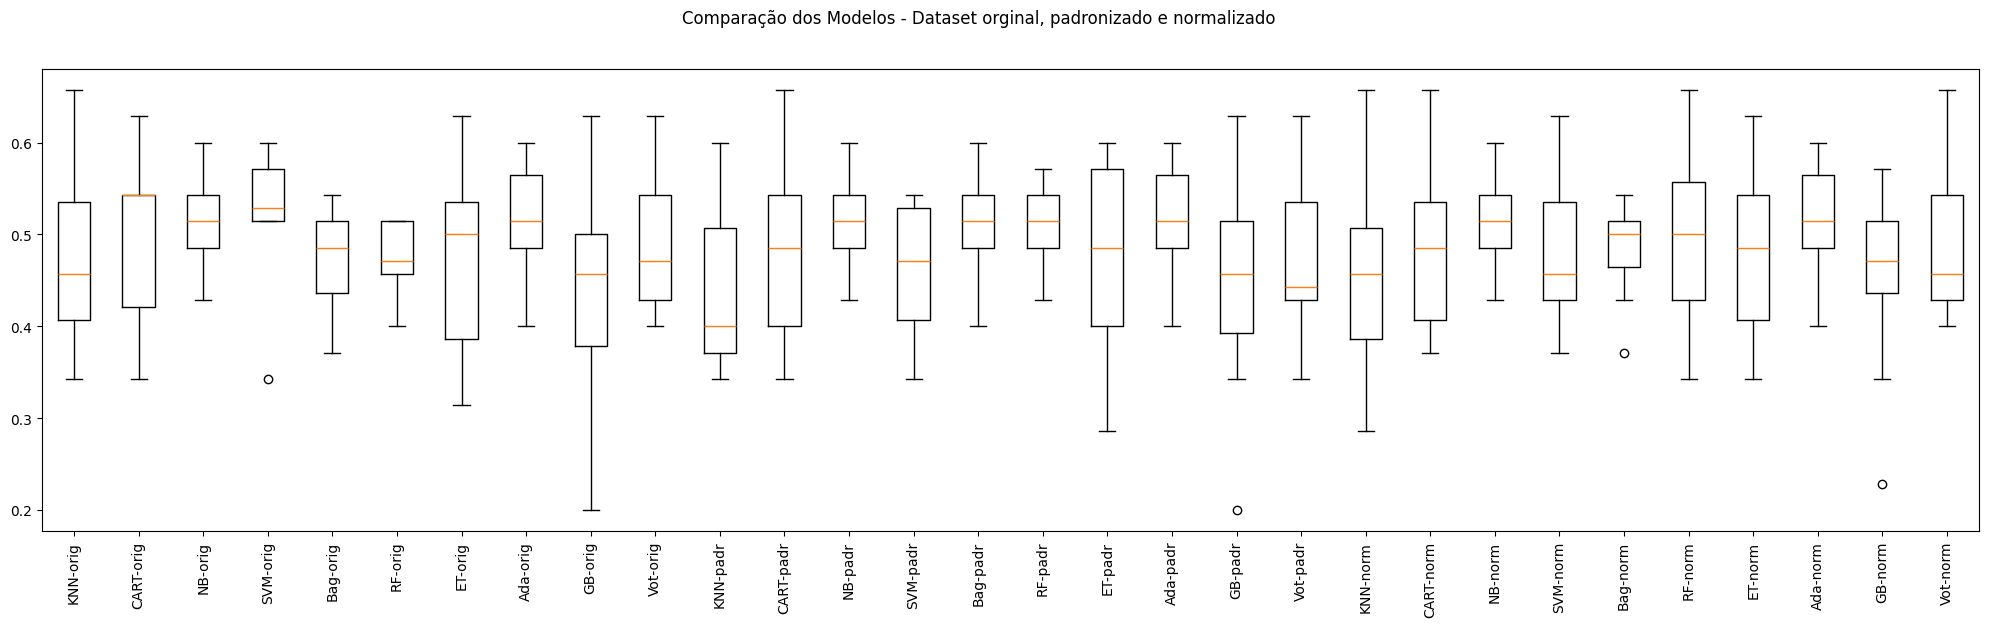

Sem tratamento de missings: knn-orig - Melhor: 0.520000 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 19}
Sem tratamento de missings: knn-padr - Melhor: 0.520000 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 15}
Sem tratamento de missings: knn-norm - Melhor: 0.545714 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 15}


LogisticRegression(max_iter=200)

In [97]:
## Cruzando K-Best com padronização e normalização
dataset_reduzido = dataset_atletas[
    ['Age', 'Height_cm', 'Training_Hours_Per_Week', 'Recovery_Days_Per_Week',
 'Rest_Between_Events_Days', 'Performance_Score', 'Load_Balance_Score',
 'ACL_Risk_Score', 'heartbeat', 'Gender_Male']
]

array = dataset_reduzido.values
X = array[:,0:9] # atributos
y = array[:,9] # classe (target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=8) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=8) # faz o particionamento em 10 folds

# Definindo uma seed global para esta célula de código
np.random.seed(SEED)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Montando os models

knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())
bagging = ('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees))
random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
voting = ('Voting', VotingClassifier(bases))


# Dataset original
models.append(('KNN-orig', Pipeline([knn])))
models.append(('CART-orig', Pipeline([cart])))
models.append(('NB-orig', Pipeline([naive_bayes])))
models.append(('SVM-orig', Pipeline([svm])))
models.append(('Bag-orig', Pipeline([bagging])))
models.append(('RF-orig', Pipeline([random_forest])))
models.append(('ET-orig', Pipeline([extra_trees])))
models.append(('Ada-orig', Pipeline([adaboost])))
models.append(('GB-orig', Pipeline([gradient_boosting])))
models.append(('Vot-orig', Pipeline([voting])))

# Dataset Padronizado
models.append(('KNN-padr', Pipeline([standard_scaler, knn])))
models.append(('CART-padr', Pipeline([standard_scaler, cart])))
models.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
models.append(('SVM-padr', Pipeline([standard_scaler, svm])))
models.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
models.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
models.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
models.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
models.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
models.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# Dataset Normalizado
models.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
models.append(('CART-norm', Pipeline([min_max_scaler, cart])))
models.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
models.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
models.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
models.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
models.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
models.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
models.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
models.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# Executando os pipelines
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()


# Tuning do KNN

np.random.seed(SEED) # definindo uma semente global para este bloco

models = []

# Definindo os componentes do pipeline
knn = ('KNN', KNeighborsClassifier())
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

models.append(('knn-orig', Pipeline(steps=[knn])))
models.append(('knn-padr', Pipeline(steps=[standard_scaler, knn])))
models.append(('knn-norm', Pipeline(steps=[min_max_scaler, knn])))

param_grid = {
    'KNN__n_neighbors': [1,3,5,7,9,11,13,15,17,19,21],
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
}

# Prepara e executa o GridSearchCV
for name, model in models:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

# Avaliação do modelo com o conjunto de testes

# Preparação do modelo
scaler = StandardScaler().fit(X_train) # ajuste do scaler com o conjunto de treino
rescaledX = scaler.transform(X_train) # aplicação da padronização no conjunto de treino
model = LogisticRegression(max_iter=200)
model.fit(rescaledX, y_train)

### 4.4.1 Acuracia

In [98]:
# Criando um modelo com todo o conjunto de treino
model = Pipeline([svm])
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)

# Estimando a acurácia no conjunto de teste
print(accuracy_score(y_test, predictions))

0.5533333333333333


# [5] Testando acuracia, F1-score, ROC-AUC

## 5.1 Baseline

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”

In [118]:
# Identificação automática simples de colunas numéricas e categóricas.

num_cols = dataset_atletas.drop(columns=TARGET).select_dtypes(include=np.number).columns.tolist()
cat_cols = dataset_atletas.drop(columns=TARGET).select_dtypes(exclude=np.number).columns.tolist()


numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ]),
        'CART': Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", DecisionTreeClassifier())
        ]),
        'NB': Pipeline(steps=[
            ("preprocess", preprocess),
            ("model",  GaussianNB())
        ])

    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))

Colunas numéricas: ['Age', 'Height_cm', 'Weight_kg', 'Training_Hours_Per_Week', 'Recovery_Days_Per_Week', 'Match_Count_Per_Week', 'Rest_Between_Events_Days', 'Fatigue_Score', 'Performance_Score', 'Team_Contribution_Score', 'Load_Balance_Score', 'ACL_Risk_Score', 'heartbeat', 'training_num', 'Gender_Male']
Colunas categóricas: []
Modelos candidatos: ['LogisticRegression', 'RandomForest', 'CART', 'NB']


In [121]:
np.random.seed(SEED)
random.seed(SEED)

PROBLEM_TYPE = "classificacao"

array = dataset_reduzido.values
X = array[:,0:9] # atributos
y = array[:,9] # classe (target)



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)




colunas = dataset_reduzido.columns[:9]

num_cols = [i for i, c in enumerate(colunas)
            if dataset_reduzido[c].dtype in ["int64", "float64"]]

cat_cols = [i for i, c in enumerate(colunas)
            if dataset_reduzido[c].dtype not in ["int64", "float64"]]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("num_cols:", num_cols[:5], "...")
print("cat_cols:", cat_cols[:5], "...")


if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyClassifier(strategy="most_frequent", random_state=SEED ))])
    candidates = {
        "LogisticRegression": Pipeline([("pre", preprocess), ("model", LogisticRegression(max_iter=200, random_state=SEED))]),
        "RandomForest": Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))]),
        "KNN": Pipeline([("pre", preprocess), ("model", KNeighborsClassifier())]),
        "CART": Pipeline([("pre", preprocess), ("model", DecisionTreeClassifier())]),
        "NB": Pipeline([("pre", preprocess), ("model", GaussianNB())]),
        'SVM': Pipeline([("pre", preprocess), ("model", SVC())]),
        'Bagging': Pipeline([("pre", preprocess), ("model", BaggingClassifier(estimator=base, n_estimators=num_trees))]),
        'RF': Pipeline([("pre", preprocess), ("model", RandomForestClassifier(n_estimators=num_trees, max_features=max_features))]),
        'ET': Pipeline([("pre", preprocess), ("model", ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))]),
        'Ada': Pipeline([("pre", preprocess), ("model", AdaBoostClassifier(n_estimators=num_trees))]),
        'GB': Pipeline([("pre", preprocess), ("model", GradientBoostingClassifier(n_estimators=num_trees))]),
        'Voting': Pipeline([("pre", preprocess), ("model", VotingClassifier(bases))])
    }
elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyRegressor(strategy="median"))])
    candidates = {
        "Ridge": Pipeline([("pre", preprocess), ("model", Ridge(random_state=SEED))]),
        "RandomForestReg": Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    }
elif PROBLEM_TYPE == "clusterizacao":
    # baseline não se aplica diretamente; use um método simples (ex.: KMeans com k fixo) como referência.
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", KMeans(n_clusters=3, random_state=SEED))])
    candidates = {
        "KMeans_k3": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=3, random_state=SEED))]),
        "KMeans_k5": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=5, random_state=SEED))])
    }
elif PROBLEM_TYPE == "serie_temporal":
    # Em séries temporais, a baseline pode ser "naive" (último valor) — aqui, apenas um placeholder.
    # Para modelos clássicos, pode considerar por exemplo Regressores com janelas (feature engineering temporal).
    baseline = None
    candidates = {}
else:
    raise ValueError("PROBLEM_TYPE inválido.")

baseline

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("num_cols:", num_cols)
print("cat_cols:", cat_cols)
print(type(X_train))


trained_models = {}
results = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    t1 = time.time()
    if PROBLEM_TYPE == "classificacao":
        y_pred = baseline.predict(X_test)
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        y_pred = baseline.predict(X_test)
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(t1 - t0, 3)
    trained_models["baseline"] = baseline

    # Candidatos
    for name, pipe in candidates.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        t1 = time.time()
        if PROBLEM_TYPE == "classificacao":
            y_pred = pipe.predict(X_test)
            proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            y_pred = pipe.predict(X_test)
            results[name] = evaluate_regression(y_test, y_pred)
        results[name]["train_time_s"] = round(t1 - t0, 3)

elif PROBLEM_TYPE == "clusterizacao":
    # Baseline e candidatos (ex.: silhouette)
    # Observação: em um projeto real, evite refit em dados de teste fora de validação apropriada.
    results["baseline"] = evaluate_clustering(X_test, baseline)
    for name, pipe in candidates.items():
        results[name] = evaluate_clustering(X_test, pipe)

elif PROBLEM_TYPE == "serie_temporal":
    # TODO: implemente métricas específicas (ex.: MAE/MAPE/RMSE out-of-time)
    results["baseline_naive"] = {"MAE": None, "MAPE": None, "RMSE": None, "obs": "Implementar baseline temporal."}

pd.DataFrame(results).T


num_cols: [0, 1, 2, 3, 4] ...
cat_cols: [] ...
X_train shape: (350, 9)
X_test shape: (150, 9)
num_cols: [0, 1, 2, 3, 4, 5, 6, 7, 8]
cat_cols: []
<class 'numpy.ndarray'>


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.533333,0.371014,0.500000,0.023
LogisticRegression,0.446667,0.439136,0.430000,0.024
RandomForest,0.573333,0.571492,0.508750,0.678
KNN,0.453333,0.451961,0.453750,0.014
CART,0.580000,0.580169,0.578571,0.019
NB,0.520000,0.510850,0.448393,0.013
SVM,0.480000,0.470088,NaN,0.035
Bagging,0.526667,0.525840,0.502321,1.217
RF,0.506667,0.506667,0.477946,0.749
ET,0.506667,0.500751,0.494732,0.268


**Resposta:**  
> Escolherei alem da baseline,Logistic Regression e RandomForest do template, a Decision Tree Classifier e Gaussian NB, por apresentarem as melhores acuracias, F1 e ROC, com menor tempo de processamento, ficando abaixo dos 0.1 Segundos.

Outros modelos ficaram com indicadores menores e processamento acima de 0.1

# [11] Otimização de Hiperparametros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.




Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

In [128]:
# === Otimização de hiperparâmetros ===

N_ITER_SEARCH = 10
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier())
    ])

    param_dist = {
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__criterion": ["gini", "entropy"]
    }

    scoring = "accuracy"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)




Fitting 10 folds for each of 10 candidates, totalling 100 fits
Melhor score na validação: 0.5742857142857143
Melhores hiperparâmetros: {'model__criterion': 'entropy', 'model__max_depth': 2, 'model__min_samples_leaf': 6, 'model__min_samples_split': 13}


Discussão da otimização#

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> Apesar de não haver impedimento por tempo, custo ou tamanho da base, sendo testa para 10 parametros, não houve melhoria na acuracia do modelo

# [12] Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.40      0.37      0.39        70
           1       0.48      0.51      0.50        80

    accuracy                           0.45       150
   macro avg       0.44      0.44      0.44       150
weighted avg       0.44      0.45      0.44       150



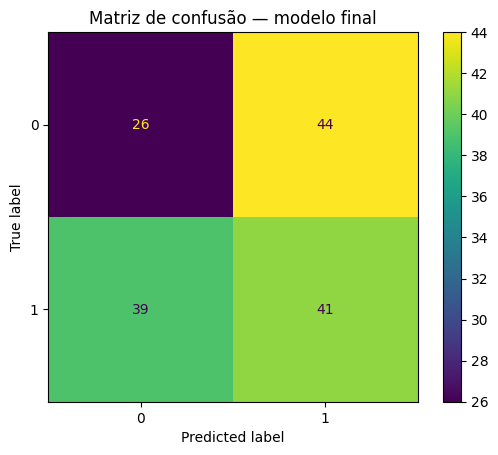

In [129]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


# [8] Testando o modelo

In [130]:
# Avaliação do modelo com o conjunto de testes

# Preparação do modelo
scaler = StandardScaler().fit(X_train) # ajuste do scaler com o conjunto de treino
rescaledX = scaler.transform(X_train) # aplicação da padronização no conjunto de treino
model = DecisionTreeClassifier()
model.fit(rescaledX, y_train)

# Estimativa da acurácia no conjunto de teste
rescaledTestX = scaler.transform(X_test) # aplicação da padronização no conjunto de teste
predictions = model.predict(rescaledTestX)
print(accuracy_score(y_test, predictions))

# Novos dados - não sabemos a classe!
entrada = pd.DataFrame({
    'Age': [34,35,60],
    'Height_cm': [177,160,180],
    'Training_Hours_Per_Week': [2,1,0],
    'Recovery_Days_Per_Week': [2,1,0],
    'Rest_Between_Events_Days':[1,1,0],
    'Performance_Score':[8,9,4],
    'Load_Balance_Score':[6,10,3],
    'ACL_Risk_Score':[6,2,8],
    'heartbeat': [80,70,50],
    'Gender_Male': [1,0,1]
})


array_entrada = entrada.values
X_entrada = array_entrada[:,0:9].astype(float)

# Padronização nos dados de entrada usando o scaler utilizado em X
rescaledEntradaX = scaler.transform(X_entrada)
print(rescaledEntradaX)


# Predição de classes dos dados de entrada
saidas = model.predict(rescaledEntradaX)
print(saidas)

0.5466666666666666
[[ 0.892  0.208 -1.279  0.95  -1.438  1.161  0.321  0.468  0.091]
 [ 1.043 -0.963 -1.522 -1.053 -1.438  1.548  1.84  -1.055 -0.759]
 [ 4.823  0.414 -1.765 -3.055 -2.025 -0.386 -0.818  1.229 -2.46 ]]
[0 1 0]


# [13] Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._


## Interprete a tabela de resultados.

Perguntas para responder:

O modelo superou o baseline?
A métrica escolhida é suficiente para avaliar o problema?
Algum modelo parece sofrer de underfitting?
O tempo de treinamento é aceitável?
O resultado faz sentido considerando a EDA?
Resposta:

Preencha aqui.

# [9] Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**
> **A Escolha do baseline com parametros reduzidos foi feito conforme os melhores parametros de acuracia, F1, AUC, e tempo de processamento, pensando na aplicação para dataset maiores**

> **Foi exigido o Hot enconding para avaliação dos modelos de Arvore de decisão,Arvore Aleatoria e outros modelos como KNN que foram analisado e retirado após estudo para melhoria de tempo de processamento, pois existiam colunas descritivas.**

> **Devido a demora de processamento de algumas normalizações ou modelos, foi selecionado os modelos mais eficientes computacionalmente.O Modelo de Suporting Vector Machine e Voting não possuí o retorno de AUC**

# [14] Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 1 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 2 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo otimizado | _preencha_ | _preencha_ | _preencha_ | _preencha_ |

# > **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.

# [14] Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |

# [15] Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.